## BTSP on a linear track

* Linear track, single direction
* CA3: 8 preset place fields
* CA1: 
  * Hebbian learning + BTSP learning at targeted neurons
  * BTSP learning: long-tailed (pre) Hebbian learning with a high output firing rate considered (occurs in one trajectory only)
  * (1) 1 cell, receives BTSP signal at a reward location
  * (2) 4 cells, with 2 receiving BTSP signals (near reward and start, respectively) 

Evaluate resulting CA1 neuron place field properties

In [1]:
import warnings

from matplotlib import pyplot as plt
import numpy as np
import ratinabox

from predhpc import agent, run_manager, plot_fcts
from predhpc.neurons import riab_neurons, learning_neurons, two_comp_neurons, object_neurons
from predhpc.util import plot_util, params_util

In [2]:
plot_util.stylize_plots_for_notebook()
ratinabox.autosave_plots = False
ratinabox.figure_directory = "figures"

In [3]:
warnings.filterwarnings(
    "ignore", message="solid 1D boundary", category=UserWarning
)
warnings.filterwarnings(
    "ignore", message="invalid value encountered", 
    category=RuntimeWarning
)

## Define some functions

In [4]:
def learn(env_params=None, agent_params=None, CA3_PC_params=None, 
          CA1_params=None, num_rewards=200, max_num_steps=5000, 
          use_Hebbian=False, BTSP_after_num_target_reaches=5, 
          two_compartment=False):
    
    if env_params is None:
        env_params = params_util.get_env_params(environment="linear")
        
    if agent_params is None:
        agent_params = params_util.get_agent_params(environment="linear")

    if CA3_PC_params is None:
        CA3_PC_params = params_util.get_CA3_PC_params(environment="linear")

    if CA1_params is None:
        CA1_params = params_util.get_CA1_params(
            environment="linear", two_compartment=two_compartment, BTSP=True
        )

    print_vals = {
        "Environment scale": env_params["scale"],
        "Agent dt": agent_params["dt"],
        "Agent target position": agent_params["target_position"],
        "# CA3 PCs": CA3_PC_params["n"], 
        "# CA1s": CA1_params["n"], 
        "CA1 init at 0": CA1_params["init_weights_zero"], 
        "CA1 init scale": CA1_params["w_init_scale"], 
        "CA1 BTSP tau": CA1_params["BTSP_filter_tau"], 
        "# rewards": num_rewards, 
        "Max # steps": max_num_steps, 
        "Hebbian learning": use_Hebbian, 
        "BTSP occurs after X number of target reaches": BTSP_after_num_target_reaches,
        "Two-compartment": two_compartment,
    }
    print_vals = [
        f"{name:16}: {value}" for name, value in print_vals.items()
    ]
    print("{}\n".format('\n'.join(print_vals)))
    
    Env, Ag, CA3_PCs, CA1s, spatial_axes, time_axes = run_manager.learn_1D_BTSP(
        env_params,
        agent_params,
        CA3_PC_params,
        CA1_params,
        num_rewards=num_rewards,
        max_num_steps=max_num_steps,
        use_Hebbian=use_Hebbian,
        BTSP_after_num_target_reaches=BTSP_after_num_target_reaches,
        two_compartment=two_compartment,
    )
    
    return Env, Ag, CA3_PCs, CA1s, spatial_axes, time_axes

## Reload

In [5]:
import importlib
importlib.reload(agent)
importlib.reload(learning_neurons)
importlib.reload(object_neurons)
importlib.reload(two_comp_neurons)
importlib.reload(run_manager)
importlib.reload(plot_util)
importlib.reload(params_util);

## Only 1 CA1 neuron

In [6]:
NUM_REWARDS = 8
MAX_NUM_STEPS = 8000
USE_HEBBIAN = False

agent_params = params_util.get_agent_params(
    environment="linear",
    target_position=params_util.SCALE_LINEAR / 2,
)

CA1_params_one = params_util.get_CA1_params(
    n=1, environment="linear", 
    two_compartment=False, BTSP=True, NMDA=False,
    init_weights_zero=False,
    w_init_scale=0,
    BTSP_lr_fact=5e3, # very high to compensate for low initial weights
    normalize_weights_divisively=True,
    regularization_alpha=0.3, 
    post_BTSP_filter_tau="half",
)

Environment scale: 3.0
Agent dt        : 0.03
Agent target position: 1.5
# CA3 PCs       : 32
# CA1s          : 1
CA1 init at 0   : False
CA1 init scale  : 0
CA1 BTSP tau    : 4
# rewards       : 8
Max # steps     : 8000
Hebbian learning: False
BTSP occurs after X number of target reaches: 4
Two-compartment : False



100%|█████████████████████████████████████| 8000/8000 [00:02<00:00, 3846.84it/s]


Only reached the reward 7 times (target: 8).
Trajectory lengths (7) to date: 34.29 +/- 3.41 sec each
Trajectory lengths (7) to date: 1142.86 +/- 113.80 steps each


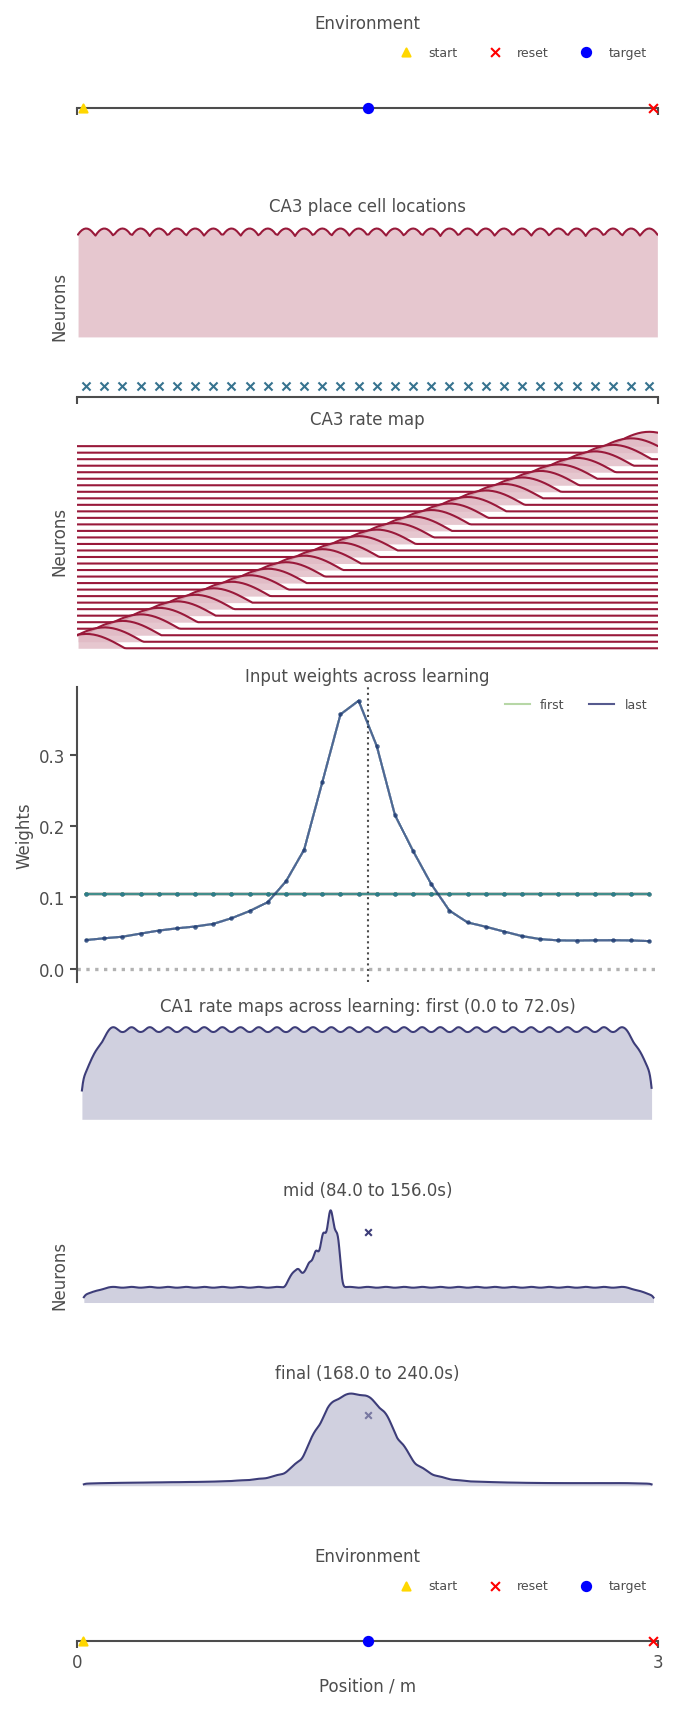

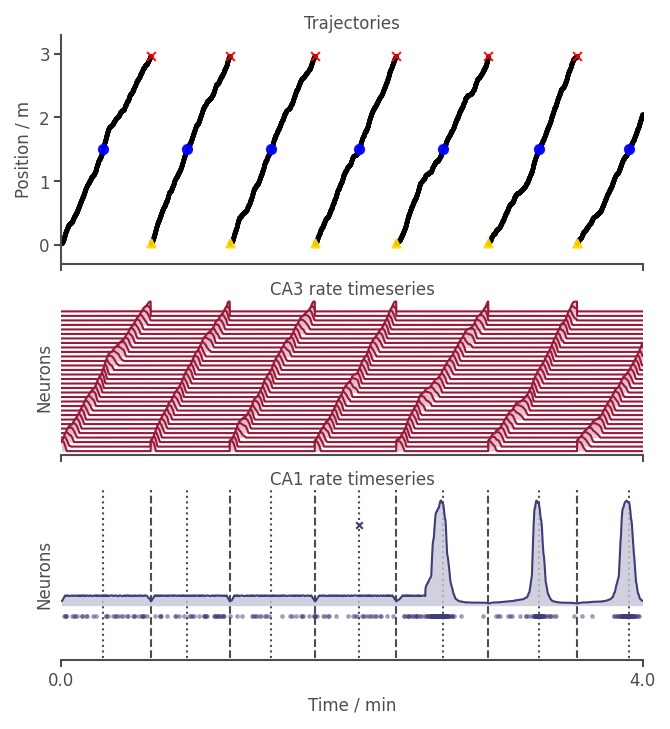

In [7]:
Env, Ag, CA3_PCs, CA1s, spatial_axes, time_axes = learn(
    agent_params=agent_params,
    CA1_params=CA1_params_one, 
    num_rewards=NUM_REWARDS, 
    max_num_steps=MAX_NUM_STEPS,
    use_Hebbian=USE_HEBBIAN,
    BTSP_after_num_target_reaches=4,
    two_compartment=False,
)

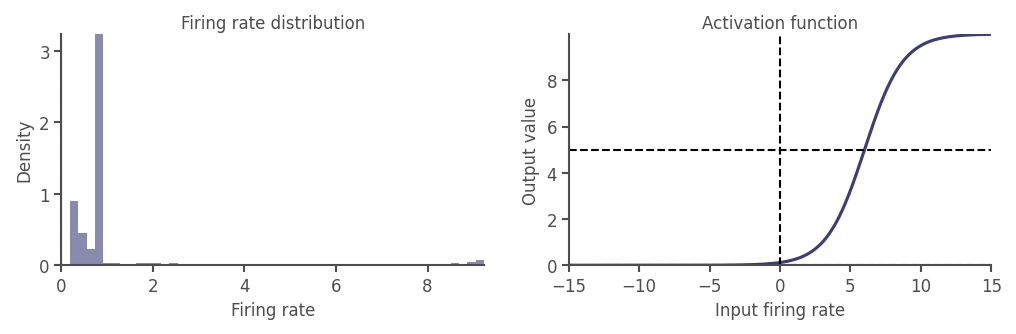

In [8]:
fig, ax1D = plt.subplots(1, 2, figsize=(8, 2))
CA1s.plot_firingrate_distribution(sub_ax=ax1D[0]);
CA1s.plot_activation_function(sub_ax=ax1D[1]);

### BTSP filters

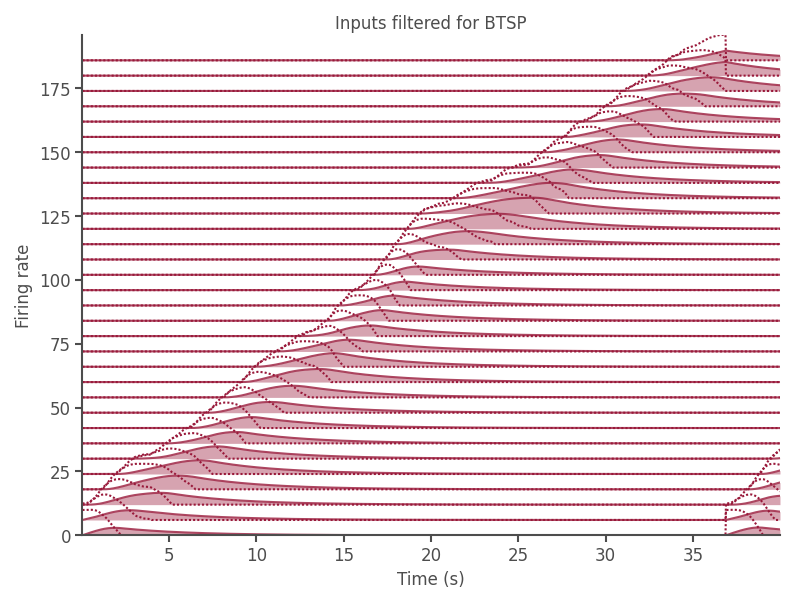

In [9]:
CA1s.plot_filtered_for_BTSP("CA3_PCs", t_end=40);

BTSP events applied after 915.00 steps (27.45 sec.) (num steps: 915).


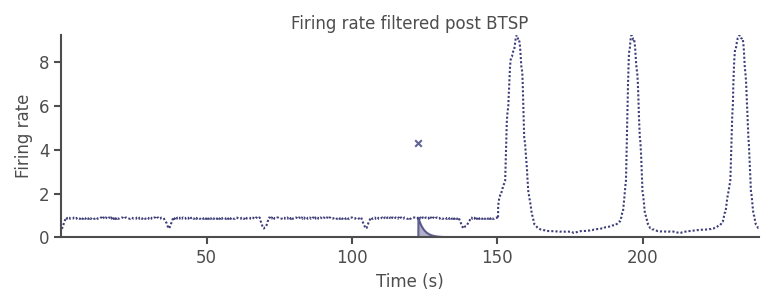

In [10]:
CA1s.log_num_steps_to_apply_BTSP()
CA1s.plot_filtered_for_BTSP();

## Multiple CA1 neurons

In [11]:
importlib.reload(run_manager)
importlib.reload(learning_neurons);

In [12]:
NUM_REWARDS = 16
MAX_NUM_STEPS = 7000
USE_HEBBIAN = True

CA1_params_mult = params_util.get_CA1_params(
    n=4, environment="linear", 
    two_compartment=False, BTSP=True, NMDA=False,
    init_weights_zero=False,
    w_init_scale=0,
    BTSP_lr_fact=5e3, # very high to compensate for Hebbian learning
    normalize_weights_divisively=True,
    regularization_alpha=0.3, # used high regularization...
)

Environment scale: 3.0
Agent dt        : 0.03
Agent target position: 2.76
# CA3 PCs       : 32
# CA1s          : 4
CA1 init at 0   : False
CA1 init scale  : 0
CA1 BTSP tau    : 4
# rewards       : 16
Max # steps     : 7000
Hebbian learning: True
BTSP occurs after X number of target reaches: 3
Two-compartment : False



100%|█████████████████████████████████████| 7000/7000 [00:01<00:00, 3518.42it/s]


Only reached the reward 6 times (target: 16).
Trajectory lengths (7) to date: 30.00 +/- 12.06 sec each
Trajectory lengths (7) to date: 1000.00 +/- 402.08 steps each


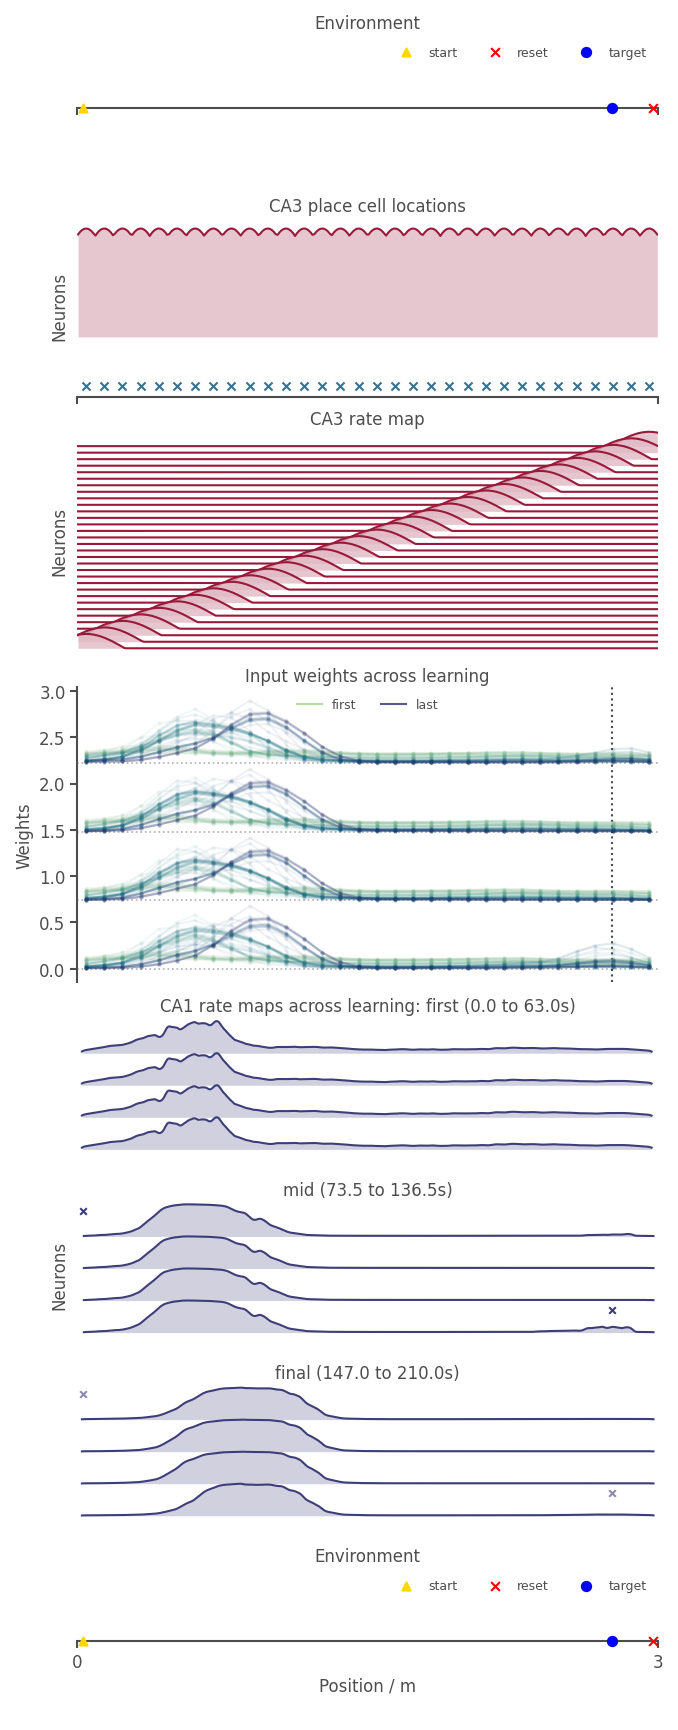

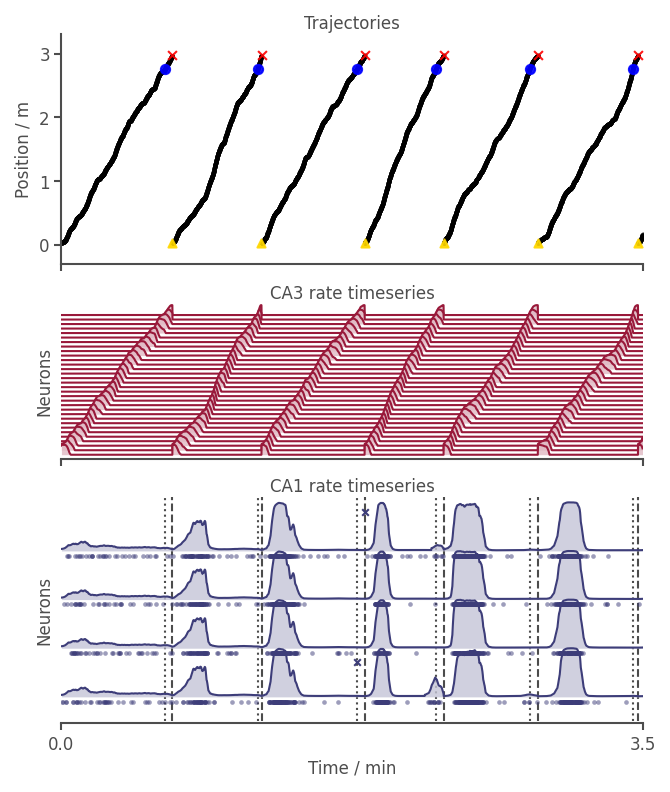

In [13]:
Env, Ag, CA3_PCs, CA1s, spatial_axes, time_axes = learn(
    CA1_params=CA1_params_mult,
    num_rewards=NUM_REWARDS, 
    max_num_steps=MAX_NUM_STEPS,
    use_Hebbian=USE_HEBBIAN,
    BTSP_after_num_target_reaches=3,
    two_compartment=False,
)

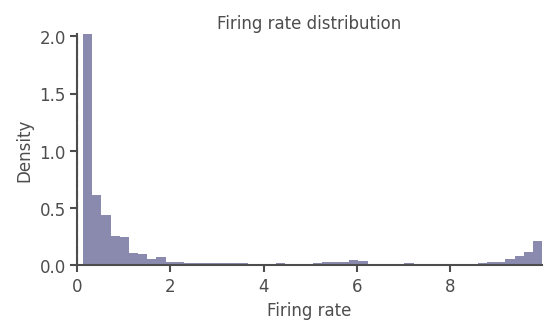

In [14]:
CA1s.plot_firingrate_distribution();

#### BTSP filters

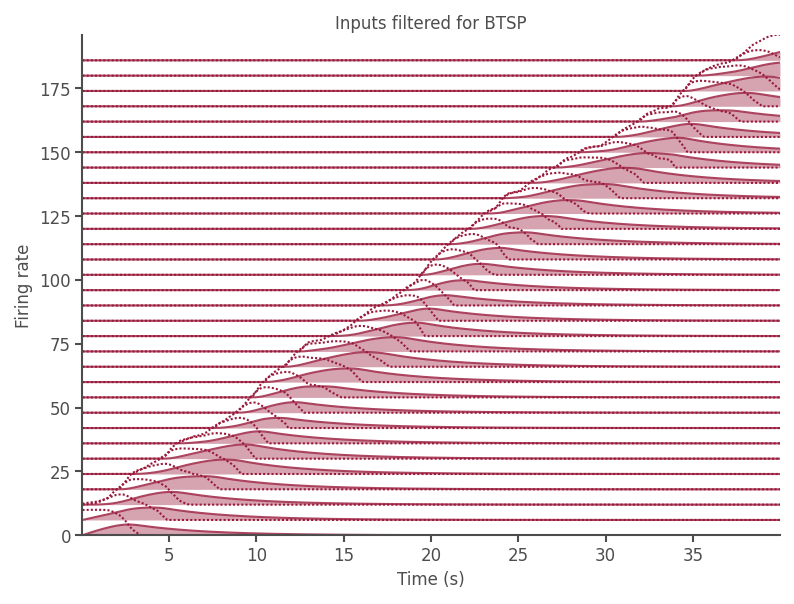

In [15]:
CA1s.plot_filtered_for_BTSP("CA3_PCs", t_start=0, t_end=40);

BTSP events applied after 808.50 steps (24.25 sec.) (num steps: 815, 802).


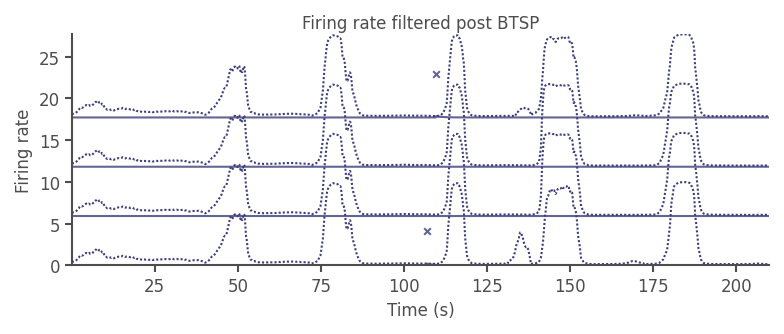

In [16]:
CA1s.log_num_steps_to_apply_BTSP()
CA1s.plot_filtered_for_BTSP();

## BTSP independent

In [17]:
from predhpc import env

import importlib
importlib.reload(learning_neurons)
importlib.reload(run_manager)
importlib.reload(plot_util)
importlib.reload(agent)

from tqdm import tqdm

In [18]:
DT = params_util.DT
SCALE = params_util.SCALE_LINEAR

env_params = params_util.get_env_params(
    scale=SCALE,
    boundary_conditions="periodic", # to avoid receptor binding discontinuity
)

agent_params = params_util.get_agent_params(dt=DT, scale=SCALE)

CA3_PC_params = params_util.get_CA3_PC_params()

CA1_params = params_util.get_CA1_params(
    n=1, environment="linear", 
    two_compartment=False, BTSP=True, 
    init_weights_zero=False,
    w_init_scale=0.2,
    BTSP_lr_fact=10, # can be very low, due to Hebbian learning
    normalize_weights_divisively=True,
    single_BTSP=True,
    regularization_alpha=0.35,
)

100%|█████████████████████████████████████| 5000/5000 [00:01<00:00, 2673.10it/s]


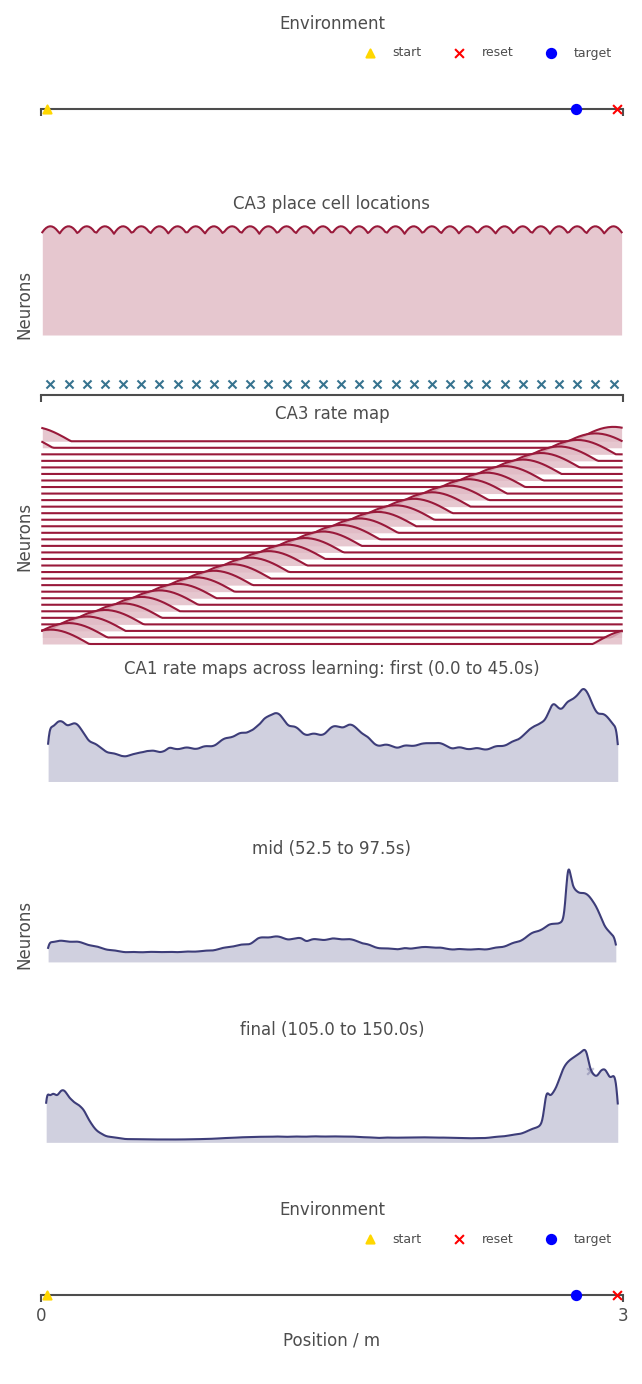

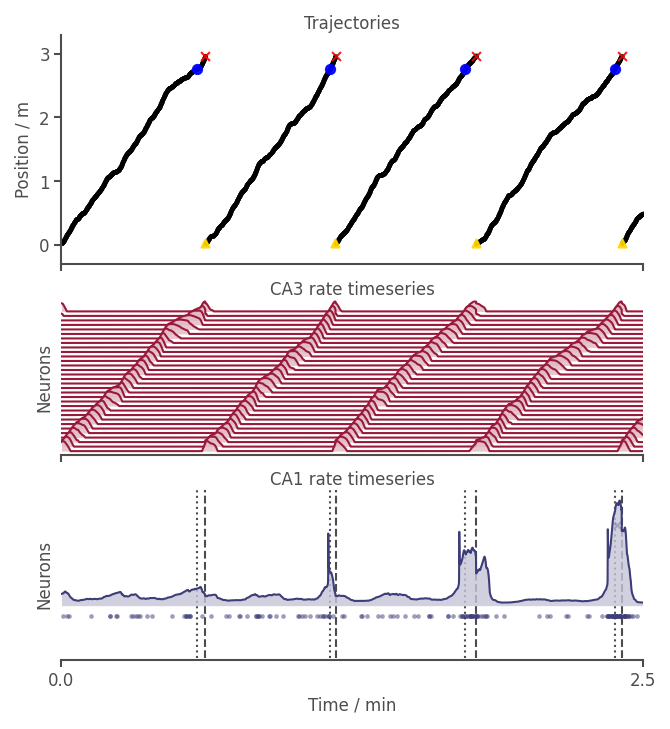

In [19]:
Env = env.Environment(params=env_params)

Ag = agent.ResetableAgent(Env, params=agent_params)
CA3_PCs = riab_neurons.PlaceCells(Ag, params=CA3_PC_params)

CA1_params["input_layers"] = [CA3_PCs]
CA1s = learning_neurons.NMDALayer(Ag, params=CA1_params)
CA1s.set_learn()
CA1s.set_BTSP_learn()

for i in tqdm(range(5000)):
    Ag.update()
    CA3_PCs.update()
    CA1s.update()

run_manager.plot_1D_spatial_info(Ag, CA3_PCs, CA1s)
run_manager.plot_1D_time_info(Ag, CA3_PCs, CA1s);

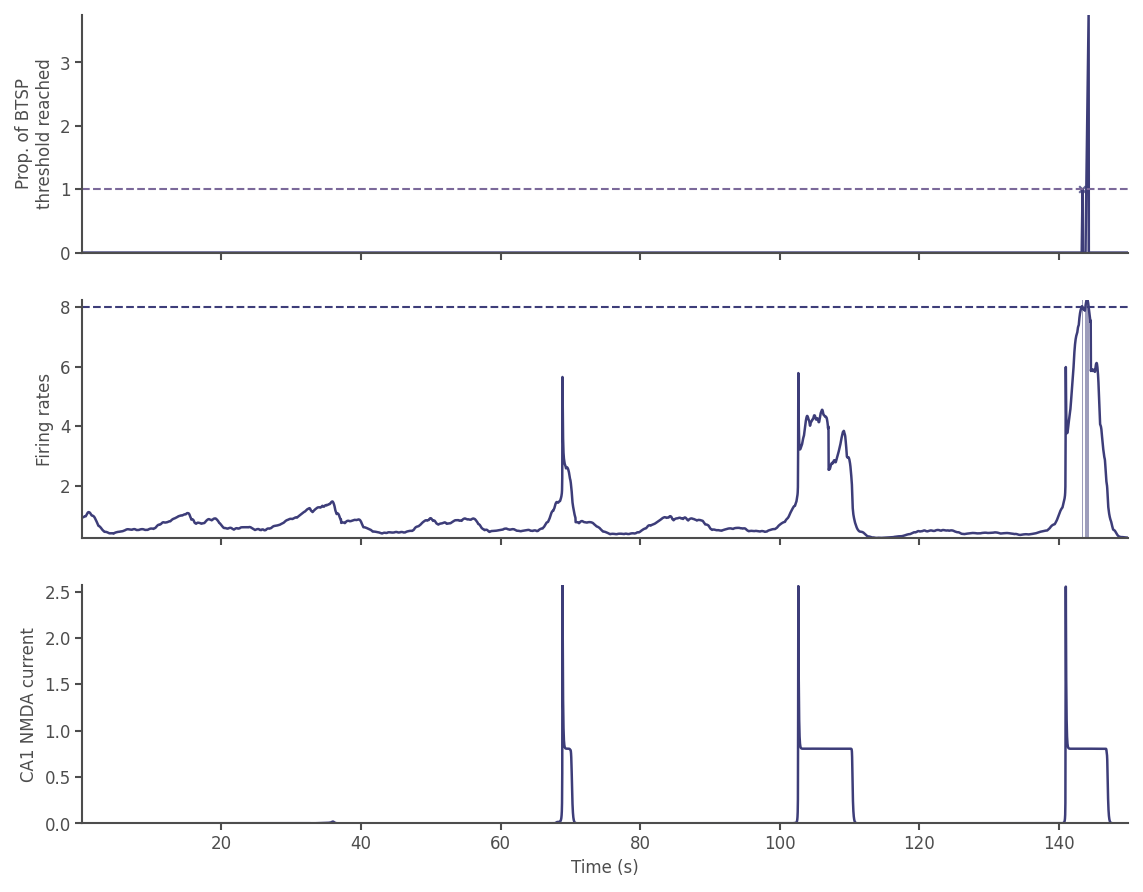

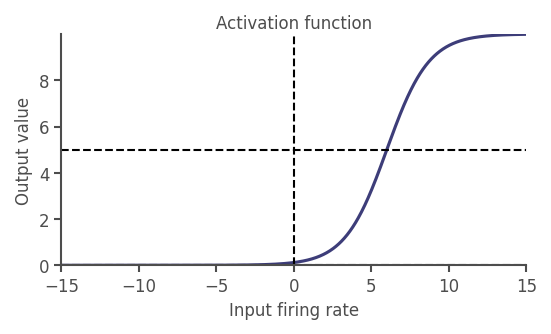

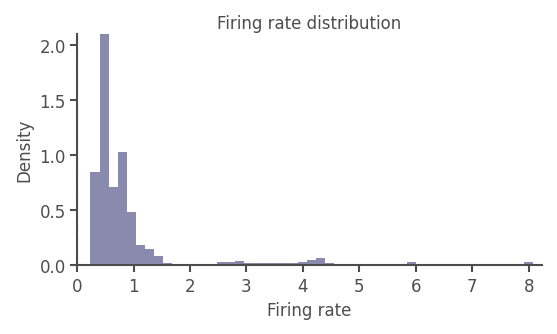

In [20]:
ax1D = CA1s.plot_BTSP_ramp()
CA1s.plot_activation_function()
CA1s.plot_firingrate_distribution();

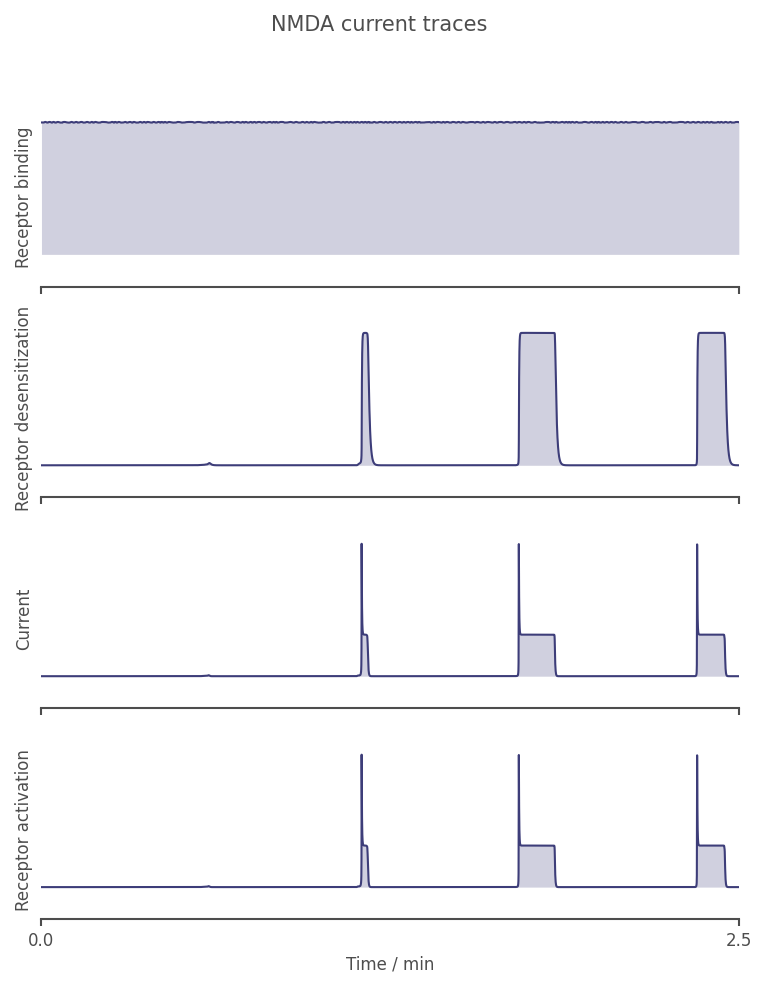

In [21]:
ax1D = CA1s.NMDACurrent.plot_timeseries(datatypes="all")

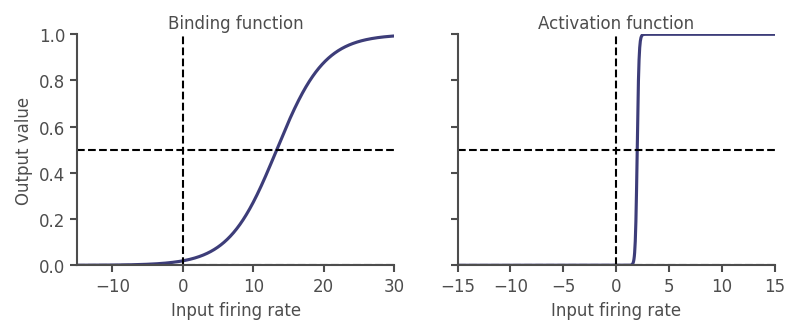

In [22]:
fig, ax1D = plt.subplots(1, 2, figsize=[6, 2], sharey=True)
CA1s.NMDACurrent.plot_function("binding", max_input_fr=30, sub_ax=ax1D[0])
CA1s.NMDACurrent.plot_function("activation", min_input_fr=-15, max_input_fr=15, sub_ax=ax1D[1])
ax1D[1].set_ylabel("");

## BTSP 2-compartment independent

In [23]:
from predhpc import env

import importlib
importlib.reload(learning_neurons)
importlib.reload(two_comp_neurons)
importlib.reload(run_manager)
importlib.reload(plot_util)
importlib.reload(params_util)
importlib.reload(agent)

from tqdm import tqdm

In [24]:
DT = params_util.DT
SCALE = params_util.SCALE_LINEAR

env_params = params_util.get_env_params(
    environment="linear",
    boundary_conditions="periodic", # to avoid receptor binding discontinuity
    scale=SCALE,
)

agent_params = params_util.get_agent_params(
    dt=DT,
    scale=SCALE,
    target_position=SCALE / 2, 
)

EC_params = params_util.get_EC_params()

CA3_PC_params = params_util.get_CA3_PC_params()

CA1_params = params_util.get_CA1_params(
    n=1, environment="linear", 
    two_compartment=True, BTSP=True,

    dend_w_init_loc=0.4,
    soma_regularization_alpha=0.6,
    soma_BTSP_lr_fact=300,  # BTSP clamp
    inhibit_weight=3,  # strength of dendritic inhibition from soma
)

In [25]:
Env = env.Environment(params=env_params)
Ag = agent.ResetableAgent(Env, params=agent_params)

ECs = object_neurons.ObjectCells(Ag, params=EC_params)
CA3_PCs = riab_neurons.PlaceCells(Ag, params=CA3_PC_params)

CA1_params["dend_input_layers"] = [ECs]
CA1_params["soma_input_layers"] = [CA3_PCs]
CA1s = two_comp_neurons.TwoCompLayer(Ag, params=CA1_params)
CA1s.set_learn(soma=False, dend=False, inhibit=False)
CA1s.set_BTSP_learn(soma=True, dend=False)

for i in tqdm(range(5000)):
    Ag.update()
    ECs.update()
    CA3_PCs.update()
    CA1s.update()

100%|█████████████████████████████████████| 5000/5000 [00:03<00:00, 1292.84it/s]


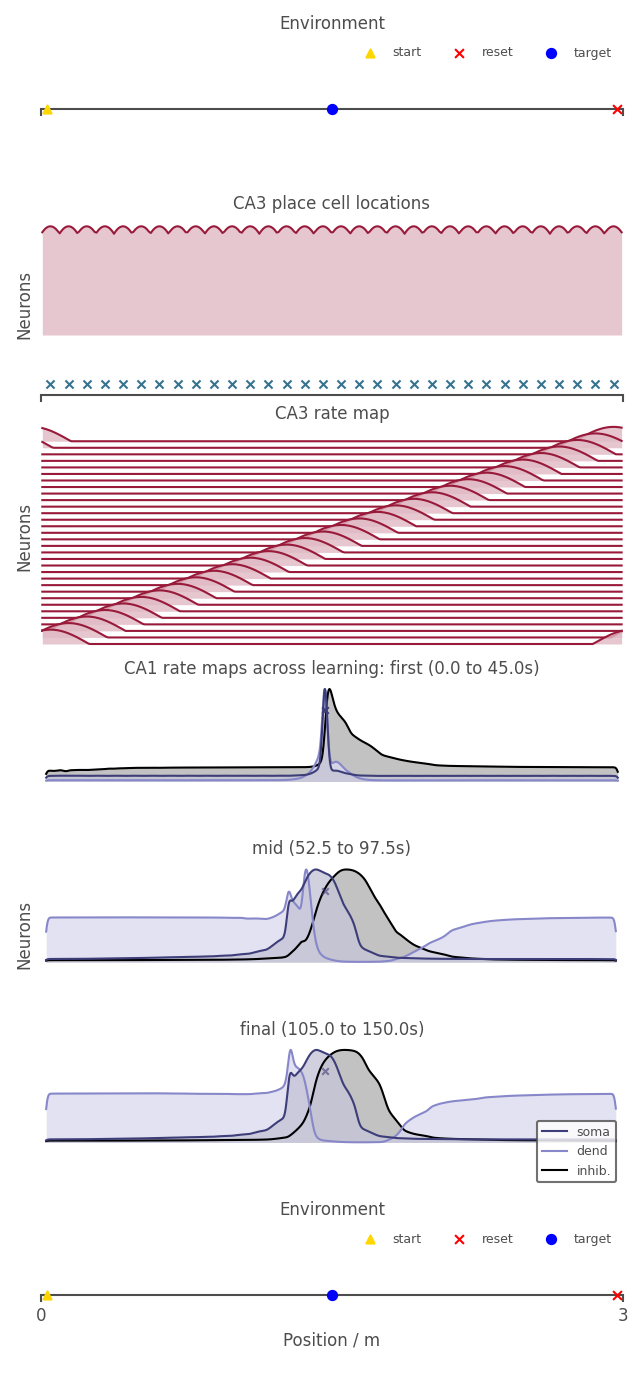

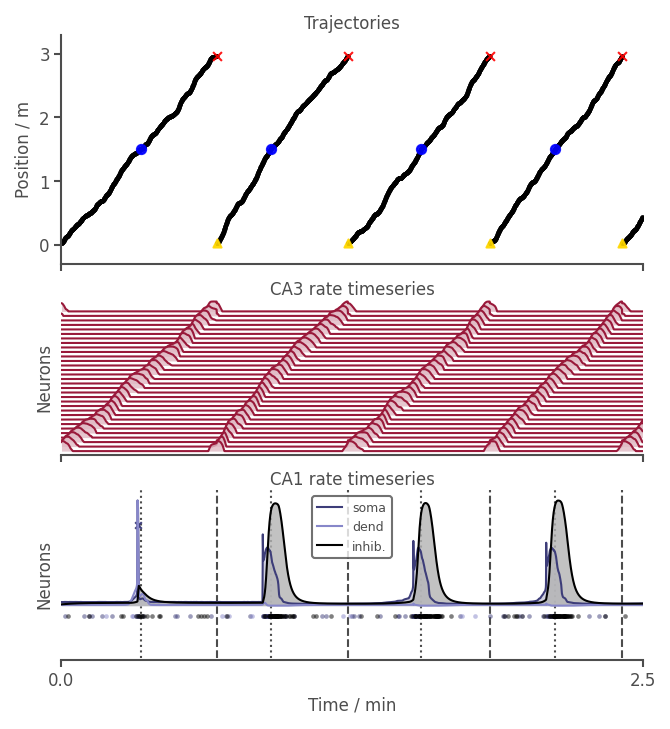

In [26]:
env_axes = run_manager.plot_1D_spatial_info(Ag, CA3_PCs, CA1s)
time_axes = run_manager.plot_1D_time_info(Ag, CA3_PCs, CA1s);

Firing rates:
  Soma: 0.1689 to 9.9197
  Dendrite: 0.0001 to 8.9485
  Inhibition: 0.1193 to 9.4550


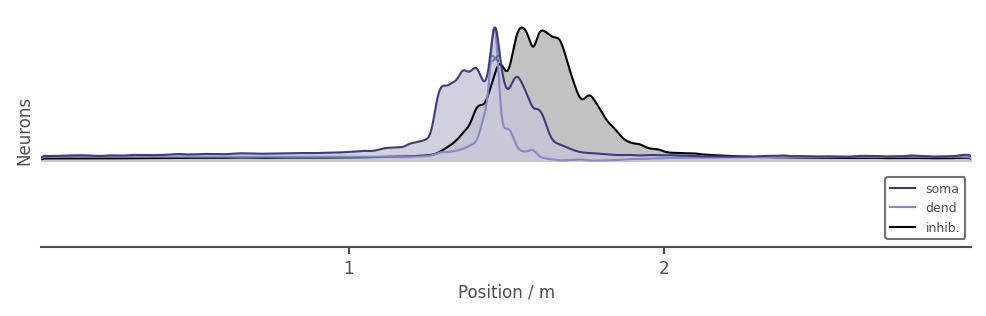

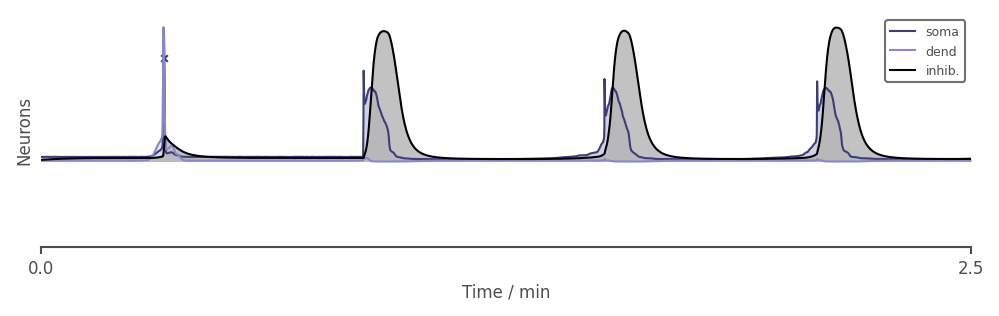

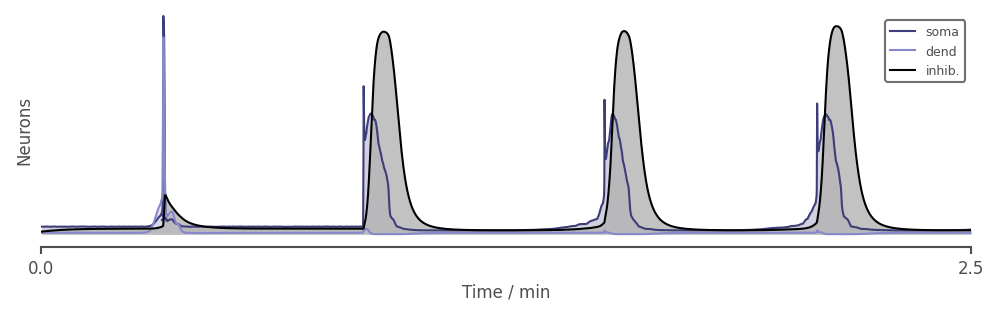

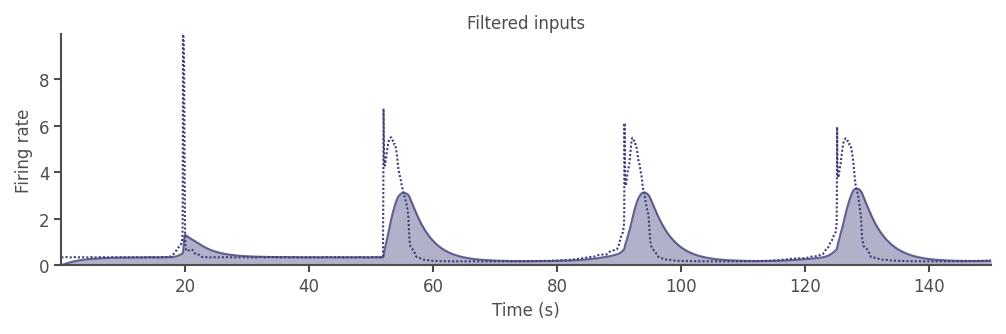

In [27]:
fig, sub_ax = plt.subplots(figsize=[8, 2])
CA1s.plot_rate_map(ax=sub_ax, t_start=-10, method="history", overlap=0.8)
fig, sub_ax = plt.subplots(figsize=[8, 2])
CA1s.plot_rate_timeseries(sub_ax=sub_ax, method="history", overlap=0.8)
fig, sub_ax = plt.subplots(figsize=[8, 2])
CA1s.plot_rate_timeseries(sub_ax=sub_ax, method="history", overlap=1, norm_by=1)
sub_ax.set_ylim(None, 11)
comp_names = ["Soma", "Dendrite", "Inhibition"]
compartments = [CA1s.SomaCompartment, CA1s.DendriteCompartment, CA1s.DendriteInhibition]
print("Firing rates:")
for comp_name, comp in zip(comp_names, compartments):
    print(
        f"  {comp_name}: {np.min(comp.history['firingrate']):.4f} to "
        f"{np.max(comp.history['firingrate']):.4f}"
)
fig, sub_ax = plt.subplots(figsize=[8, 2])
CA1s.DendriteInhibition.plot_filtered("CA1_TwoComp_soma", sub_ax=sub_ax);

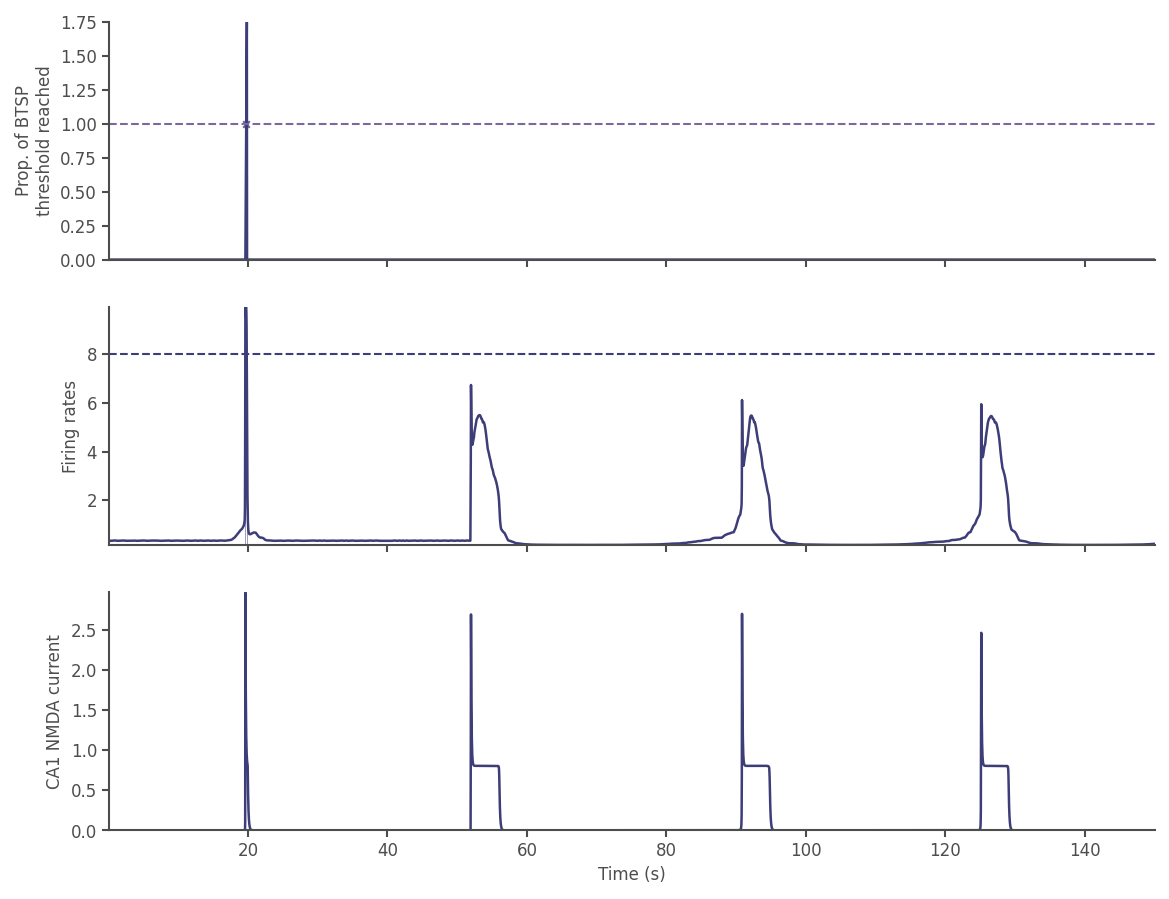

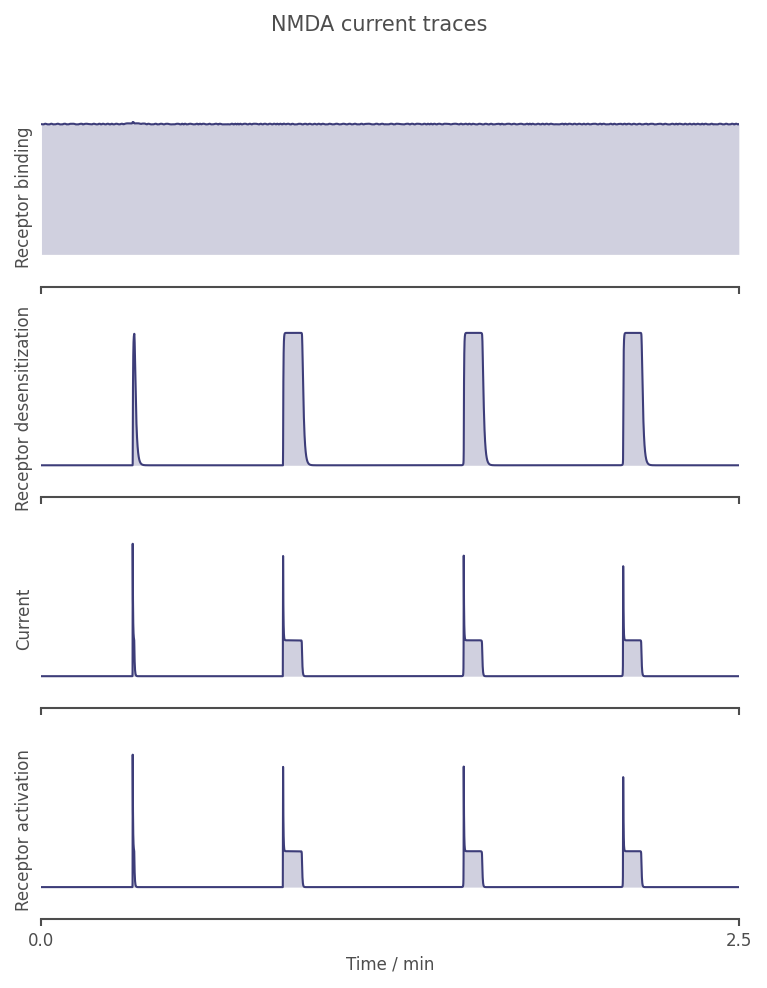

In [28]:
CA1s.SomaCompartment.plot_BTSP_ramp()
CA1s.SomaCompartment.NMDACurrent.plot_timeseries(datatypes="all");

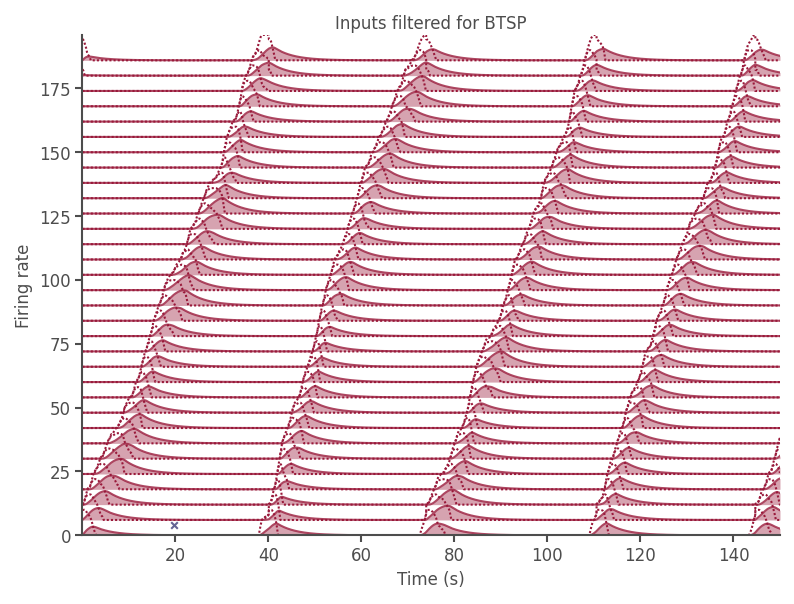

In [29]:
CA1s.SomaCompartment.plot_filtered_for_BTSP("CA3_PCs");

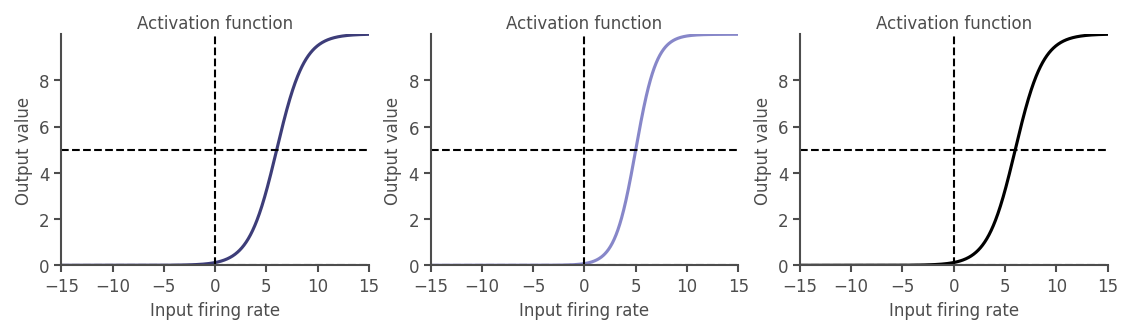

In [30]:
fig, ax1D = plt.subplots(1, 3, figsize=[9, 2])
CA1s.SomaCompartment.plot_activation_function(sub_ax=ax1D[0])
CA1s.DendriteCompartment.plot_activation_function(sub_ax=ax1D[1])
CA1s.DendriteInhibition.plot_activation_function(sub_ax=ax1D[2]);

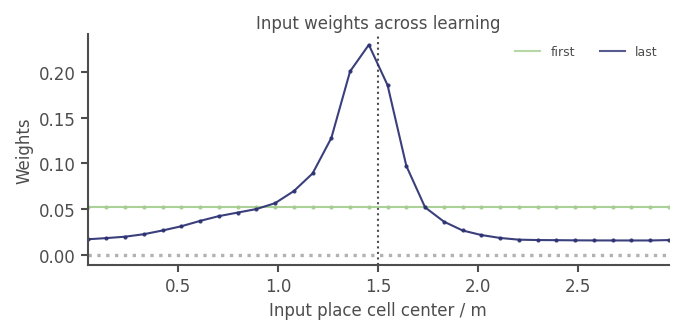

In [31]:
ws = [CA1s.SomaCompartment.inputs["CA3_PCs"][key] for key in ["w_init", "w"]]
plot_fcts.plot_1D_input_place_cell_weights(ws, CA3_PCs);

BTSP events applied after 1073.00 steps (32.19 sec.) (num steps: 1073).


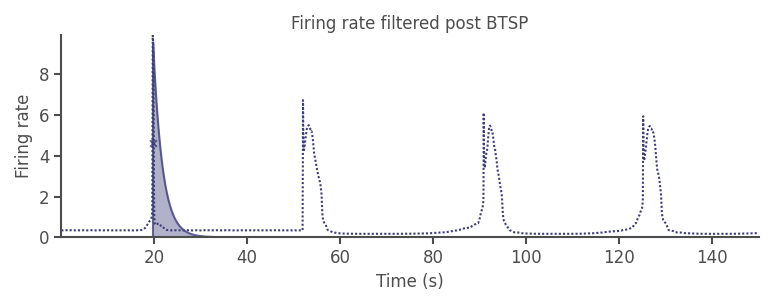

In [32]:
CA1s.SomaCompartment.log_num_steps_to_apply_BTSP()
CA1s.SomaCompartment.plot_filtered_for_BTSP();